### Importación de datos



In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)


#1. Análisis de facturación



In [46]:

def calcular_ingresos_tienda(df, nombre_tienda):

    posibles_columnas = ['Precio', 'price', 'Price', 'PRECIO', 'valor', 'Valor']
    columna_precio = None

    for col in posibles_columnas:
        if col in df.columns:
            columna_precio = col
            break

    if columna_precio is None:

        for col in df.columns:
            if 'precio' in col.lower():
                columna_precio = col
                break

    if columna_precio:
        ingreso_total = df[columna_precio].sum()
        print(f"{nombre_tienda}:")
        print(f"  Columna usada: '{columna_precio}'")
        print(f"  Ingreso total: ${ingreso_total:,.2f}")
        print(f"  Número de transacciones: {len(df)}")
        print(f"  Precio promedio: ${df[columna_precio].mean():,.2f}")
        return ingreso_total
    else:
        print(f"{nombre_tienda}: No se pudo encontrar columna de precios")
        print(f"Columnas disponibles: {df.columns.tolist()}")
        return 0

print("**** INGRESOS TOTALES POR TIENDA ****")
ingresos = []
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
datasets = [tienda, tienda2, tienda3, tienda4]

for nombre, df in zip(nombres_tiendas, datasets):
    ingreso = calcular_ingresos_tienda(df, nombre)
    ingresos.append(ingreso)

print(f"\n=== RESUMEN EJECUTIVO ===")
for nombre, ingreso in zip(nombres_tiendas, ingresos):
    print(f"{nombre}: ${ingreso:,.2f}")



**** INGRESOS TOTALES POR TIENDA ****
Tienda 1:
  Columna usada: 'Precio'
  Ingreso total: $1,150,880,400.00
  Número de transacciones: 2359
  Precio promedio: $487,867.91
Tienda 2:
  Columna usada: 'Precio'
  Ingreso total: $1,116,343,500.00
  Número de transacciones: 2359
  Precio promedio: $473,227.43
Tienda 3:
  Columna usada: 'Precio'
  Ingreso total: $1,098,019,600.00
  Número de transacciones: 2359
  Precio promedio: $465,459.77
Tienda 4:
  Columna usada: 'Precio'
  Ingreso total: $1,038,375,700.00
  Número de transacciones: 2358
  Precio promedio: $440,362.89

=== RESUMEN EJECUTIVO ===
Tienda 1: $1,150,880,400.00
Tienda 2: $1,116,343,500.00
Tienda 3: $1,098,019,600.00
Tienda 4: $1,038,375,700.00


# 2. Ventas por categoría

In [47]:
# Primero identifiquemos las columnas relacionadas con categorías
print("=== IDENTIFICANDO COLUMNAS DE CATEGORÍAS ===")
for i, df in enumerate([tienda, tienda2, tienda3, tienda4], 1):
    print(f"\nTienda {i} - Columnas que podrían ser de categoría:")
    categoria_cols = [col for col in df.columns if 'categor' in col.lower() or 'category' in col.lower() or 'tipo' in col.lower() or 'producto' in col.lower()]
    print(categoria_cols)
    if categoria_cols:
        print(f"Valores únicos en '{categoria_cols[0]}':")
        print(df[categoria_cols[0]].value_counts().head())

=== IDENTIFICANDO COLUMNAS DE CATEGORÍAS ===

Tienda 1 - Columnas que podrían ser de categoría:
['Producto', 'Categoría del Producto']
Valores únicos en 'Producto':
Producto
Microondas          60
TV LED UHD 4K       60
Armario             60
Secadora de ropa    58
Mesa de noche       56
Name: count, dtype: int64

Tienda 2 - Columnas que podrían ser de categoría:
['Producto', 'Categoría del Producto']
Valores únicos en 'Producto':
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Guitarra acústica            58
Pandereta                    58
Name: count, dtype: int64

Tienda 3 - Columnas que podrían ser de categoría:
['Producto', 'Categoría del Producto']
Valores únicos en 'Producto':
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche      55
Name: count, dtype: int64

Tienda 4 - Columnas que podrían ser de categoría:
['Producto', 'Categoría del Producto']
Valores únicos 

In [48]:
def productos_por_categoria(df, nombre_tienda):

    posibles_columnas = ['Categoría', 'Categoria', 'categoría', 'categoria', 'Category', 'category', 'Tipo', 'tipo']
    columna_categoria = None

    for col in posibles_columnas:
        if col in df.columns:
            columna_categoria = col
            break

    if columna_categoria is None:
        for col in df.columns:
            if 'categor' in col.lower():
                columna_categoria = col
                break

    if columna_categoria:
        productos_por_cat = df[columna_categoria].value_counts().reset_index()
        productos_por_cat.columns = ['Categoría', 'Cantidad_Vendida']
        productos_por_cat = productos_por_cat.sort_values('Cantidad_Vendida', ascending=False)

        print(f"\n{'='*60}")
        print(f"PRODUCTOS POR CATEGORÍA - {nombre_tienda}")
        print(f"{'='*60}")
        print(f"Columna usada: '{columna_categoria}'")
        print(f"Total de categorías: {len(productos_por_cat)}")
        print(f"Total de productos vendidos: {productos_por_cat['Cantidad_Vendida'].sum()}")
        print(f"\nTop 10 categorías más vendidas:")
        print("-" * 40)

        for idx, row in productos_por_cat.head(10).iterrows():
            print(f"{row['Categoría']}: {row['Cantidad_Vendida']} unidades")

        return productos_por_cat
    else:
        print(f"\n{nombre_tienda}: No se pudo encontrar columna de categorías")
        print(f"Columnas disponibles: {df.columns.tolist()}")
        return None



resultados_categorias = {}

for i, (nombre, df) in enumerate(zip(['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
                                    [tienda, tienda2, tienda3, tienda4])):
    resultado = productos_por_categoria(df, nombre)
    resultados_categorias[nombre] = resultado



PRODUCTOS POR CATEGORÍA - Tienda 1
Columna usada: 'Categoría del Producto'
Total de categorías: 8
Total de productos vendidos: 2359

Top 10 categorías más vendidas:
----------------------------------------
Muebles: 465 unidades
Electrónicos: 448 unidades
Juguetes: 324 unidades
Electrodomésticos: 312 unidades
Deportes y diversión: 284 unidades
Instrumentos musicales: 182 unidades
Libros: 173 unidades
Artículos para el hogar: 171 unidades

PRODUCTOS POR CATEGORÍA - Tienda 2
Columna usada: 'Categoría del Producto'
Total de categorías: 8
Total de productos vendidos: 2359

Top 10 categorías más vendidas:
----------------------------------------
Muebles: 442 unidades
Electrónicos: 422 unidades
Juguetes: 313 unidades
Electrodomésticos: 305 unidades
Deportes y diversión: 275 unidades
Instrumentos musicales: 224 unidades
Libros: 197 unidades
Artículos para el hogar: 181 unidades

PRODUCTOS POR CATEGORÍA - Tienda 3
Columna usada: 'Categoría del Producto'
Total de categorías: 8
Total de producto

# 3. Calificación promedio de la tienda


In [49]:
def calcular_calificaciones_promedio(df, nombre_tienda):

    # Buscar columna de calificaciones
    posibles_columnas = ['Calificación', 'Calificacion', 'calificación', 'calificacion',]

    columna_calificacion = None

    # Búsqueda exacta
    for col in posibles_columnas:
        if col in df.columns:
            columna_calificacion = col
            break

    # Búsqueda flexible
    if columna_calificacion is None:
        for col in df.columns:
            if any(word in col.lower() for word in ['calif', 'rating', 'score', 'evalu', 'puntu', 'nota']):
                columna_calificacion = col
                break

    if columna_calificacion:
        try:
            # Convertir a numérico por si hay valores no numéricos
            calificaciones_numericas = pd.to_numeric(df[columna_calificacion], errors='coerce')

            # Filtrar valores nulos después de la conversión
            calificaciones_validas = calificaciones_numericas.dropna()

            if len(calificaciones_validas) > 0:
                promedio = calificaciones_validas.mean()
                mediana = calificaciones_validas.median()
                cantidad_calificaciones = len(calificaciones_validas)
                porcentaje_calificados = (len(calificaciones_validas) / len(df)) * 100

                print(f"\n{'='*60}")
                print(f"CALIFICACIONES - {nombre_tienda}")
                print(f"{'='*60}")
                print(f"Columna usada: '{columna_calificacion}'")
                print(f"Calificación promedio: {promedio:.2f}/5")
                print(f"Mediana: {mediana:.2f}/5")
                print(f"Total de calificaciones: {cantidad_calificaciones}")
                print(f"Porcentaje de ventas calificadas: {porcentaje_calificados:.1f}%")

                # Distribución de calificaciones
                print(f"\nDistribución de calificaciones:")
                distribucion = calificaciones_validas.value_counts().sort_index()
                for calif, count in distribucion.items():
                    porcentaje = (count / cantidad_calificaciones) * 100
                    print(f"  {calif} estrellas: {count} ({porcentaje:.1f}%)")

                return {
                    'promedio': promedio,
                    'mediana': mediana,
                    'total_calificaciones': cantidad_calificaciones,
                    'porcentaje_calificados': porcentaje_calificados,
                    'distribucion': distribucion
                }
            else:
                print(f"\n{nombre_tienda}: Columna '{columna_calificacion}' encontrada pero no hay valores numéricos válidos")
                return None

        except Exception as e:
            print(f"\n{nombre_tienda}: Error procesando calificaciones - {e}")
            return None
    else:
        print(f"\n{nombre_tienda}: No se pudo encontrar columna de calificaciones")
        print(f"Columnas disponibles: {df.columns.tolist()}")
        return None

# Ejecutar para todas las tiendas
print("*** ANÁLISIS DE CALIFICACIONES PROMEDIO ***")
resultados_calificaciones = {}

for i, (nombre, df) in enumerate(zip(['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
                                    [tienda, tienda2, tienda3, tienda4])):
    resultado = calcular_calificaciones_promedio(df, nombre)
    resultados_calificaciones[nombre] = resultado


*** ANÁLISIS DE CALIFICACIONES PROMEDIO ***

CALIFICACIONES - Tienda 1
Columna usada: 'Calificación'
Calificación promedio: 3.98/5
Mediana: 5.00/5
Total de calificaciones: 2359
Porcentaje de ventas calificadas: 100.0%

Distribución de calificaciones:
  1 estrellas: 319 (13.5%)
  2 estrellas: 86 (3.6%)
  3 estrellas: 218 (9.2%)
  4 estrellas: 444 (18.8%)
  5 estrellas: 1292 (54.8%)

CALIFICACIONES - Tienda 2
Columna usada: 'Calificación'
Calificación promedio: 4.04/5
Mediana: 5.00/5
Total de calificaciones: 2359
Porcentaje de ventas calificadas: 100.0%

Distribución de calificaciones:
  1 estrellas: 273 (11.6%)
  2 estrellas: 93 (3.9%)
  3 estrellas: 209 (8.9%)
  4 estrellas: 482 (20.4%)
  5 estrellas: 1302 (55.2%)

CALIFICACIONES - Tienda 3
Columna usada: 'Calificación'
Calificación promedio: 4.05/5
Mediana: 5.00/5
Total de calificaciones: 2359
Porcentaje de ventas calificadas: 100.0%

Distribución de calificaciones:
  1 estrellas: 297 (12.6%)
  2 estrellas: 79 (3.3%)
  3 estrellas: 19

# 4. Productos más y menos vendidos

In [50]:
def analizar_productos_vendidos(df, nombre_tienda, top_n=10):

    # Buscar columna de productos
    posibles_columnas = ['Producto', 'producto', 'Product', 'product',]

    columna_producto = None

    # Fase 1: Búsqueda exacta
    for col in posibles_columnas:
        if col in df.columns:
            columna_producto = col
            break

    # Fase 2: Búsqueda flexible
    if columna_producto is None:
        for col in df.columns:
            if any(word in col.lower() for word in ['product', 'item', 'articulo', 'nombre']):
                columna_producto = col
                break

    if columna_producto:
        # Contar ventas por producto
        ventas_por_producto = df[columna_producto].value_counts().reset_index()
        ventas_por_producto.columns = ['Producto', 'Cantidad_Vendida']
        ventas_por_producto = ventas_por_producto.sort_values('Cantidad_Vendida', ascending=False)

        # Productos más vendidos (top N)
        productos_top = ventas_por_producto.head(top_n)

        # Productos menos vendidos (bottom N, excluyendo los que se vendieron 0 veces)
        productos_menos = ventas_por_producto[ventas_por_producto['Cantidad_Vendida'] > 0].tail(top_n)

        print(f"\n{'='*70}")
        print(f"ANÁLISIS DE PRODUCTOS - {nombre_tienda}")
        print(f"{'='*70}")
        print(f"Columna usada: '{columna_producto}'")
        print(f"Total de productos distintos: {len(ventas_por_producto)}")
        print(f"Total de ventas registradas: {ventas_por_producto['Cantidad_Vendida'].sum()}")

        # Mostrar productos más vendidos
        print(f"\n🏆 TOP {top_n} PRODUCTOS MÁS VENDIDOS:")
        print("-" * 50)
        for idx, row in productos_top.iterrows():
            print(f"{idx + 1:2d}. {row['Producto']}: {row['Cantidad_Vendida']} unidades")

        # Mostrar productos menos vendidos
        print(f"\n📉 TOP {top_n} PRODUCTOS MENOS VENDIDOS:")
        print("-" * 50)
        for idx, row in productos_menos.iterrows():
            posicion = len(ventas_por_producto) - top_n + idx + 1
            print(f"{posicion:2d}. {row['Producto']}: {row['Cantidad_Vendida']} unidad(es)")

        return {
            'ventas_por_producto': ventas_por_producto,
            'productos_top': productos_top,
            'productos_menos': productos_menos,
            'total_productos': len(ventas_por_producto),
            'total_ventas': ventas_por_producto['Cantidad_Vendida'].sum()
        }
    else:
        print(f"\n{nombre_tienda}: No se pudo encontrar columna de productos")
        print(f"Columnas disponibles: {df.columns.tolist()}")
        return None

# Ejecutar para todas las tiendas
print("*** ANÁLISIS DE PRODUCTOS MÁS Y MENOS VENDIDOS ***")
resultados_productos = {}

for i, (nombre, df) in enumerate(zip(['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
                                    [tienda, tienda2, tienda3, tienda4])):
    resultado = analizar_productos_vendidos(df, nombre, top_n=8)
    resultados_productos[nombre] = resultado

*** ANÁLISIS DE PRODUCTOS MÁS Y MENOS VENDIDOS ***

ANÁLISIS DE PRODUCTOS - Tienda 1
Columna usada: 'Producto'
Total de productos distintos: 51
Total de ventas registradas: 2359

🏆 TOP 8 PRODUCTOS MÁS VENDIDOS:
--------------------------------------------------
 1. Microondas: 60 unidades
 2. TV LED UHD 4K: 60 unidades
 3. Armario: 60 unidades
 4. Secadora de ropa: 58 unidades
 5. Mesa de noche: 56 unidades
 6. Bloques de construcción: 56 unidades
 7. Balón de baloncesto: 55 unidades
 8. Bicicleta: 54 unidades

📉 TOP 8 PRODUCTOS MENOS VENDIDOS:
--------------------------------------------------
87. Dinosaurio Rex: 40 unidad(es)
88. Cuerda para saltar: 40 unidad(es)
89. Mochila: 39 unidad(es)
90. Ciencia de datos con Python: 39 unidad(es)
91. Pandereta: 36 unidad(es)
92. Olla de presión: 35 unidad(es)
93. Auriculares con micrófono: 33 unidad(es)
94. Celular ABXY: 33 unidad(es)

ANÁLISIS DE PRODUCTOS - Tienda 2
Columna usada: 'Producto'
Total de productos distintos: 51
Total de ventas re

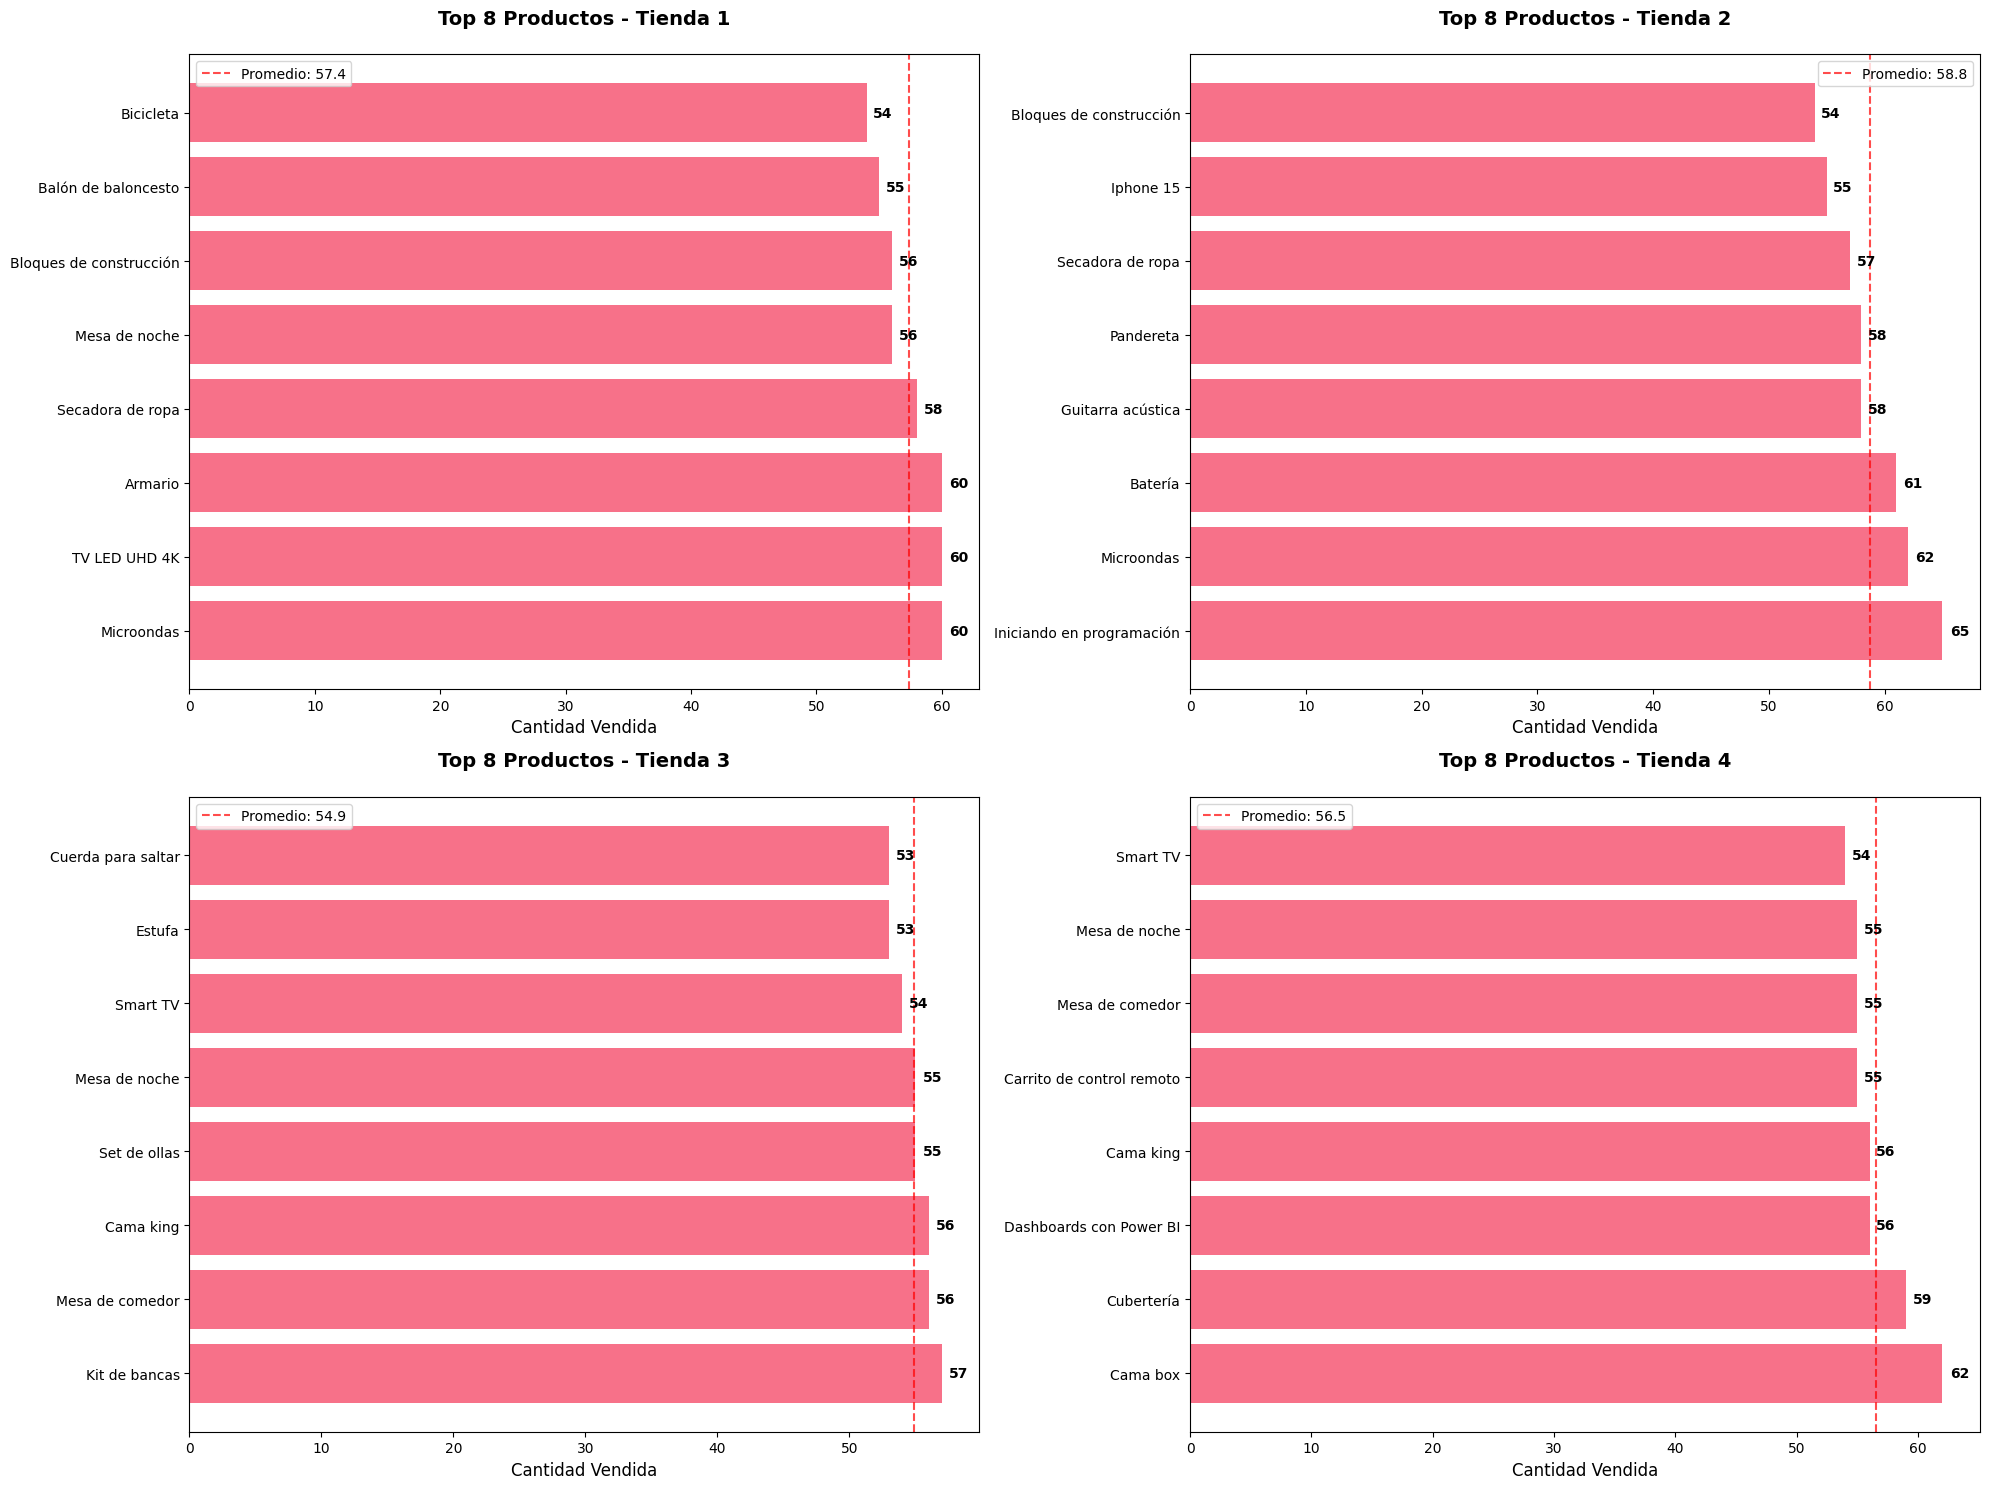

In [51]:
# Configurar el estilo
plt.style.use('default')
sns.set_palette("husl")

# Crear visualizaciones para cada tienda
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

for i, (nombre_tienda, resultado) in enumerate(resultados_productos.items()):
    if resultado is not None:
        ax = axes[i]

        # Tomar top 8 productos para mejor visualización
        top_productos = resultado['productos_top'].head(8)

        # Crear gráfico de barras horizontales
        bars = ax.barh(top_productos['Producto'], top_productos['Cantidad_Vendida'])
        ax.set_title(f'Top 8 Productos - {nombre_tienda}\n', fontsize=14, fontweight='bold')
        ax.set_xlabel('Cantidad Vendida', fontsize=12)

        # Mejorar la legibilidad de los nombres de productos
        ax.tick_params(axis='y', labelsize=10)

        # Agregar valores en las barras
        for bar, valor in zip(bars, top_productos['Cantidad_Vendida']):
            ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                   f'{valor}', va='center', ha='left', fontsize=10, fontweight='bold')

        # Agregar línea de promedio
        promedio_ventas = top_productos['Cantidad_Vendida'].mean()
        ax.axvline(promedio_ventas, color='red', linestyle='--', alpha=0.7, label=f'Promedio: {promedio_ventas:.1f}')
        ax.legend()

plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [52]:
def calcular_costos_envio(df, nombre_tienda):

    # Buscar columna de costos de envío
    posibles_columnas = ['Costo de envío', 'Costo de envio', 'Costo_envío', 'Costo_envio',]

    columna_envio = None

    # Búsqueda exacta
    for col in posibles_columnas:
        if col in df.columns:
            columna_envio = col
            break

    # Búsqueda flexible
    if columna_envio is None:
        for col in df.columns:
            col_lower = col.lower()
            if any(word in col_lower for word in ['envío', 'envio', 'shipping', 'costo env', 'freight']):
                columna_envio = col
                break

    if columna_envio:
        try:
            # Convertir a numérico por si hay valores no numéricos
            costos_numericos = pd.to_numeric(df[columna_envio], errors='coerce')

            # Filtrar valores nulos después de la conversión
            costos_validos = costos_numericos.dropna()

            if len(costos_validos) > 0:
                # Cálculos estadísticos
                promedio = costos_validos.mean()
                mediana = costos_validos.median()
                total_envios = len(costos_validos)
                costo_total = costos_validos.sum()
                porcentaje_con_envio = (len(costos_validos) / len(df)) * 100

                print(f"\n{'='*60}")
                print(f"COSTOS DE ENVÍO - {nombre_tienda}")
                print(f"{'='*60}")
                print(f"Columna usada: '{columna_envio}'")
                print(f"Costo de envío promedio: ${promedio:.2f}")
                print(f"Mediana: ${mediana:.2f}")
                print(f"Rango: ${costos_validos.min():.2f} - ${costos_validos.max():.2f}")
                print(f"Total de envíos registrados: {total_envios}")
                print(f"Porcentaje de ventas con envío: {porcentaje_con_envio:.1f}%")
                print(f"Costo total en envíos: ${costo_total:,.2f}")

                # Distribución de costos
                print(f"\nDistribución de costos de envío:")
                # Crear categorías de costos
                bins = [0, 5, 10, 15, 20, 50, 100, float('inf')]
                labels = ['$0-5', '$5-10', '$10-15', '$15-20', '$20-50', '$50-100', '$100+']
                distribucion = pd.cut(costos_validos, bins=bins, labels=labels, right=False).value_counts().sort_index()

                for rango, count in distribucion.items():
                    porcentaje = (count / total_envios) * 100
                    print(f"  {rango}: {count} envíos ({porcentaje:.1f}%)")

                return {
                    'promedio': promedio,
                    'mediana': mediana,
                    'total_envios': total_envios,
                    'costo_total': costo_total,
                    'porcentaje_con_envio': porcentaje_con_envio,
                    'distribucion': distribucion,
                    'costos_validos': costos_validos
                }
            else:
                print(f"\n{nombre_tienda}: Columna '{columna_envio}' encontrada pero no hay valores numéricos válidos")
                return None

        except Exception as e:
            print(f"\n{nombre_tienda}: Error procesando costos de envío - {e}")
            return None
    else:
        print(f"\n{nombre_tienda}: No se pudo encontrar columna de costos de envío")
        print(f"Columnas disponibles: {df.columns.tolist()}")
        return None

# Ejecutar para todas las tiendas
print("*** ANÁLISIS DE COSTOS DE ENVÍO PROMEDIO ***")
resultados_envios = {}

for i, (nombre, df) in enumerate(zip(['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
                                    [tienda, tienda2, tienda3, tienda4])):
    resultado = calcular_costos_envio(df, nombre)
    resultados_envios[nombre] = resultado


*** ANÁLISIS DE COSTOS DE ENVÍO PROMEDIO ***

COSTOS DE ENVÍO - Tienda 1
Columna usada: 'Costo de envío'
Costo de envío promedio: $26018.61
Mediana: $12400.00
Rango: $0.00 - $160800.00
Total de envíos registrados: 2359
Porcentaje de ventas con envío: 100.0%
Costo total en envíos: $61,377,900.00

Distribución de costos de envío:
  $0-5: 209 envíos (8.9%)
  $5-10: 0 envíos (0.0%)
  $10-15: 0 envíos (0.0%)
  $15-20: 0 envíos (0.0%)
  $20-50: 0 envíos (0.0%)
  $50-100: 0 envíos (0.0%)
  $100+: 2150 envíos (91.1%)

COSTOS DE ENVÍO - Tienda 2
Columna usada: 'Costo de envío'
Costo de envío promedio: $25216.24
Mediana: $11600.00
Rango: $0.00 - $162500.00
Total de envíos registrados: 2359
Porcentaje de ventas con envío: 100.0%
Costo total en envíos: $59,485,100.00

Distribución de costos de envío:
  $0-5: 214 envíos (9.1%)
  $5-10: 0 envíos (0.0%)
  $10-15: 0 envíos (0.0%)
  $15-20: 0 envíos (0.0%)
  $20-50: 0 envíos (0.0%)
  $50-100: 0 envíos (0.0%)
  $100+: 2145 envíos (90.9%)

COSTOS DE ENVÍ